In [1]:
ls

all_data_decomposed_100ms_1core.csv
all_data_decomposed_100ms_apiserver.csv
all_data_decomposed_100ms.csv
all_data_decomposed_100ms_hybrid.csv
all_data_decomposed_10ms_1core.csv
all_data_decomposed_10ms_apiserver.csv
all_data_decomposed_10ms.csv
all_data_decomposed_10ms_hybrid.csv
all_data_decomposed_10s_1core.csv
all_data_decomposed_10s_apiserver.csv
all_data_decomposed_10s.csv
all_data_decomposed_1s_1core.csv
all_data_decomposed_1s_apiserver.csv
all_data_decomposed_1s.csv
all_data_decomposed_1s_hybrid.csv
all_data_decomposed_200ms_1core.csv
all_data_decomposed_200ms_apiserver.csv
all_data_decomposed_200ms.csv
all_data_decomposed_200ms_hybrid.csv
all_data_decomposed_2s_1core.csv
all_data_decomposed_2s_apiserver.csv
all_data_decomposed_2s.csv
all_data_decomposed_50ms_1core.csv
all_data_decomposed_50ms_apiserver.csv
all_data_decomposed_50ms.csv
all_data_decomposed_50ms_hybrid.csv
all_data_decomposed_controller_100ms.csv
all_data_decomposed_controller_10ms.csv
all_data_decomposed_control

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Available delays: ['10ms', '50ms', '100ms', '200ms', '1s', '2s', '10s']
✓ fig_ecdf_iot.pdf / .png


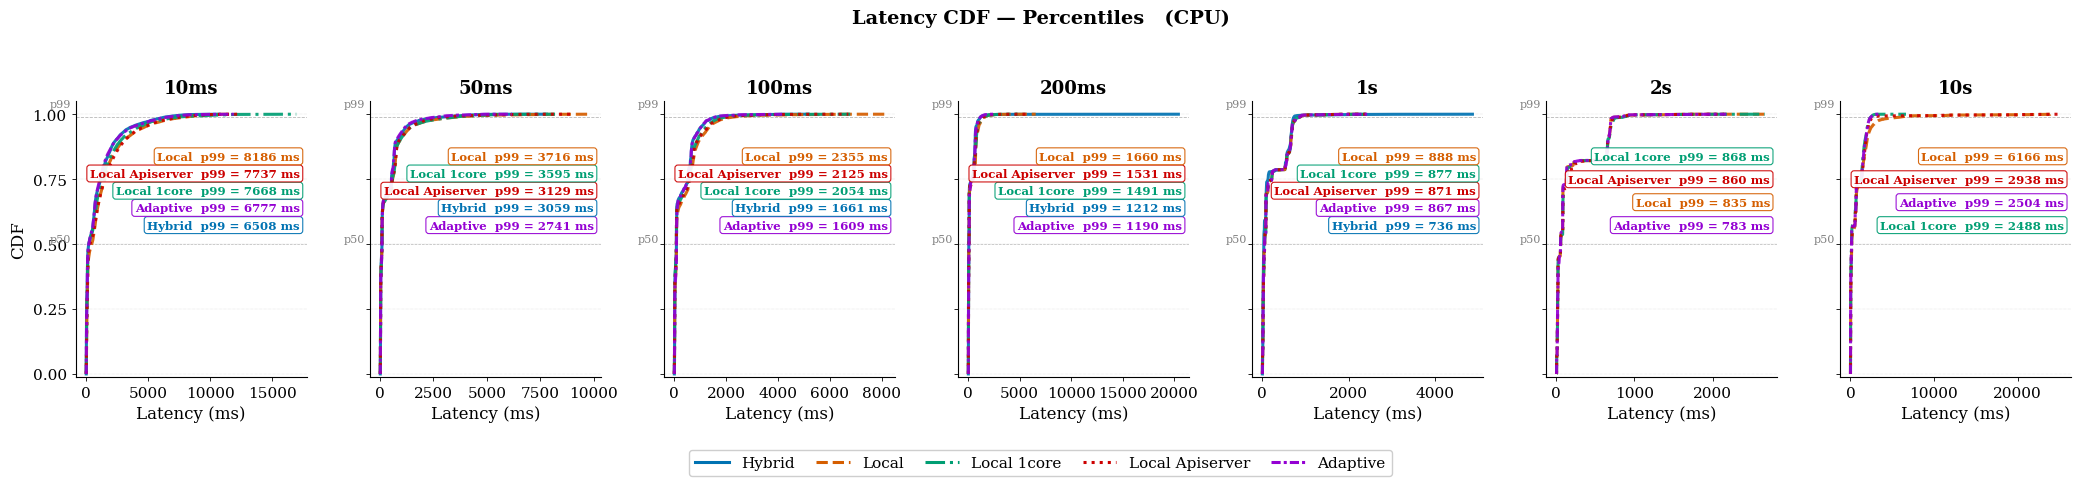

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.lines import Line2D

# ──  ───────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         13,
    "axes.titlesize":    14,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "lines.linewidth":   2.2,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ──  ────────────────────
STYLES = {
    "Hybrid":           ("#0072B2", "-"),
    "Local":             ("#D55E00", "--"),
    "Local 1core":       ("#009E73", "-."),
    "Local Apiserver":   ("#CC0000", ":"),
    "Adaptive":          ("#9400D3", (0, (3, 1, 1, 1))),  # violet, dash-dot-dot
}
MODES = list(STYLES.keys())

# ── Config ────────────────────────────────────────────────────────────────────
DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s", "2s", "10s"]  # <- 2s et 5s ajoutes
DATA_DIR = "."
FILES = {
    "Local":            {d: f"all_data_decomposed_{d}.csv"            for d in DELAYS},
    "Local 1core":       {d: f"all_data_decomposed_{d}_1core.csv"      for d in DELAYS},
    "Hybrid":            {d: f"all_data_decomposed_{d}_hybrid.csv"     for d in DELAYS},
    "Local Apiserver":   {d: f"all_data_decomposed_{d}_apiserver.csv"  for d in DELAYS},
    "Adaptive":          {d: f"all_data_decomposed_controller_{d}.csv"      for d in DELAYS},
}


# ── Helpers ───────────────────────────────────────────────────────────────────
def load_series(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)["latency_ms"].dropna()
    return s if len(s) > 0 else None


def ecdf(data):
    xs = np.sort(data)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys


available = [d for d in DELAYS if any(load_series(m, d) is not None for m in MODES)]
print(f"Available delays: {available}")

# ── Layout ────────────────────────────────────────────────────────────────────
n     = len(available)
COL_W = 3.0
fig, axes = plt.subplots(1, n, figsize=(COL_W * n, 4.2), sharey=True)
if n == 1:
    axes = [axes]

for ci, delay in enumerate(available):
    ax = axes[ci]

    # p99 / p50 horizontal guide lines
    ax.axhline(0.99, color="0.72", linewidth=0.6, linestyle="--", zorder=1)
    ax.text(-0.02, 0.99, "p99", transform=ax.transAxes,
            ha="right", va="center", fontsize=8, color="0.50")
    ax.axhline(0.50, color="0.72", linewidth=0.5, linestyle="--", zorder=1)
    ax.text(-0.02, 0.50, "p50", transform=ax.transAxes,
            ha="right", va="center", fontsize=8, color="0.50")

    # Collect p99 per arch for stacked annotations
    p99_entries = []

    for arch in MODES:
        data = load_series(arch, delay)
        if data is None:
            continue
        color, ls = STYLES[arch]
        xs, ys = ecdf(data.values)
        ax.plot(xs, ys, color=color, linestyle=ls, linewidth=2.2,
                alpha=0.92, zorder=3)
        p99_val = float(np.percentile(data, 99))
        p99_entries.append((p99_val, color, arch))

    # ── p99 annotations — stacked, no arrows, no lines ───────────────────
    p99_entries.sort(key=lambda x: x[0])
    n_arches  = len(p99_entries)
    y_offsets = np.linspace(0.55, 0.80, n_arches)   # axes fraction

    for idx, (p99_val, color, arch) in enumerate(p99_entries):
        label = f"{arch}  p99 = {p99_val:.0f} ms"
        ax.text(
            0.97, y_offsets[idx],
            label,
            transform=ax.transAxes,
            ha="right", va="center",
            fontsize=8.5,
            color=color,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor=color,
                linewidth=0.8,
                alpha=0.92,
            ),
            zorder=6,
        )

    ax.set_title(delay, fontweight="bold", fontsize=13, pad=6)
    ax.set_xlabel("Latency (ms)", fontsize=12, labelpad=4)
    ax.set_ylim(-0.01, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.tick_params(axis="both", direction="out", length=3, width=0.6)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.35, color="0.80", zorder=0)
    ax.grid(False, axis="x")

    if ci == 0:
        ax.set_ylabel("CDF", fontsize=12)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color=STYLES[a][0], linestyle=STYLES[a][1],
           linewidth=2.2, label=a)
    for a in MODES
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(MODES),
    bbox_to_anchor=(0.5, -0.10),
    fontsize=11,
    framealpha=0.95,
    edgecolor="0.80",
    handlelength=2.2,
    columnspacing=1.4,
)

fig.suptitle("Latency CDF — Percentiles   (CPU)",
             fontsize=14, fontweight="bold", y=1.03)

plt.tight_layout(rect=[0, 0.0, 1, 1.0])

fig.savefig("fig_ecdf_iot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_ecdf_iot.png", dpi=300, bbox_inches="tight")
print("✓ fig_ecdf_iot.pdf / .png")

Available delays: ['10ms', '50ms', '100ms', '200ms', '1s', '2s', '10s']


/tmp/ipykernel_464591/1572492905.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ fig_p99_bars_cpu.pdf / .png


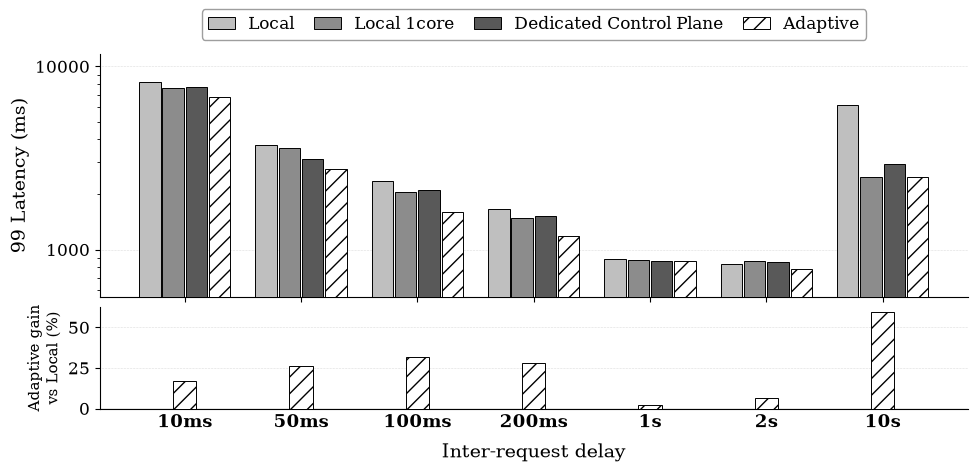

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# ── T ───────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         13,
    "axes.titlesize":    14,
    "axes.labelsize":    14,
    "xtick.labelsize":   13,
    "ytick.labelsize":   12,
    "legend.fontsize":   12,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Palette: grayscale + hatching (B&W-safe, no Hybrid) ──────────────────────
STYLES = {
    "Local":                  {"color": "0.75", "hatch": None},
    "Local 1core":            {"color": "0.55", "hatch": None},
    "Dedicated Control Plane": {"color": "0.35", "hatch": None},
    "Adaptive":               {"color": "white", "hatch": "//"},
}
MODES = list(STYLES.keys())

# ── Config ────────────────────────────────────────────────────────────────────
DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s", "2s", "10s"]
DATA_DIR = "."
FILES = {
    "Local":                  {d: f"all_data_decomposed_{d}.csv"            for d in DELAYS},
    "Local 1core":            {d: f"all_data_decomposed_{d}_1core.csv"      for d in DELAYS},
    "Dedicated Control Plane": {d: f"all_data_decomposed_{d}_apiserver.csv" for d in DELAYS},
    "Adaptive":               {d: f"all_data_decomposed_controller_{d}.csv" for d in DELAYS},
}


def load_series(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)["latency_ms"].dropna()
    return s if len(s) > 0 else None


# ── Compute p99 per (mode, delay) ─────────────────────────────────────────────
available = [d for d in DELAYS if any(load_series(m, d) is not None for m in MODES)]
print(f"Available delays: {available}")

p99 = {m: [] for m in MODES}
for d in available:
    for m in MODES:
        data = load_series(m, d)
        p99[m].append(float(np.percentile(data, 99)) if data is not None else np.nan)

# ── Reduction of Adaptive vs. Local (naive fixed baseline), per delay ────────
reduction_pct = []
for j in range(len(available)):
    local_val = p99["Local"][j]
    adapt_val = p99["Adaptive"][j]
    if not np.isnan(local_val) and not np.isnan(adapt_val):
        reduction_pct.append(100 * (local_val - adapt_val) / local_val)
    else:
        reduction_pct.append(np.nan)

# ── Figure: top = grouped p99 bars (log scale), bottom = % reduction ─────────
n_delays = len(available)
n_modes  = len(MODES)
x        = np.arange(n_delays)
width    = 0.8 / n_modes

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(max(7, 1.6 * n_delays), 4.6),
    sharex=True, gridspec_kw={"height_ratios": [2.4, 1], "hspace": 0.06},
)

for i, m in enumerate(MODES):
    offset = (i - (n_modes - 1) / 2) * width
    ax.bar(
        x + offset, p99[m], width=width * 0.92,
        color=STYLES[m]["color"], hatch=STYLES[m]["hatch"],
        edgecolor="black", linewidth=0.7, label=m, zorder=3,
    )

ax.set_ylabel("99 Latency (ms)")
ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.75", zorder=0)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.margins(y=0.15)

ax.legend(
    loc="upper center", ncol=n_modes, bbox_to_anchor=(0.5, 1.22),
    frameon=True, framealpha=0.95, edgecolor="0.6", handlelength=1.6,
    columnspacing=1.2,
)

# ── Bottom panel: % reduction of Adaptive vs best static baseline ────────────
bar_colors = ["0.10" if v >= 0 else "0.75" for v in reduction_pct]
ax2.bar(x, reduction_pct, width=0.2, color="white", edgecolor="black",hatch="//",
        linewidth=0.7, zorder=3)
ax2.axhline(0, color="black", linewidth=0.8, zorder=2)
ax2.set_ylabel("Adaptive gain\nvs Local (%)", fontsize=11)
ax2.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.75", zorder=0)

ax2.set_xlabel("Inter-request delay", labelpad=8)
ax2.set_xticks(x)
ax2.set_xticklabels(available, fontweight="bold")
ax2.tick_params(axis="x", length=0)

plt.tight_layout()
fig.savefig("fig_p99_bars_cpu.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_p99_bars_cpu.png", dpi=300, bbox_inches="tight")
print("✓ fig_p99_bars_cpu.pdf / .png")

Delays (cold): ['10ms', '50ms', '100ms', '200ms', '1s']


/tmp/ipykernel_2608713/777011050.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.0, 1, 1.0])


✓ fig_ecdf_iot.pdf / .png


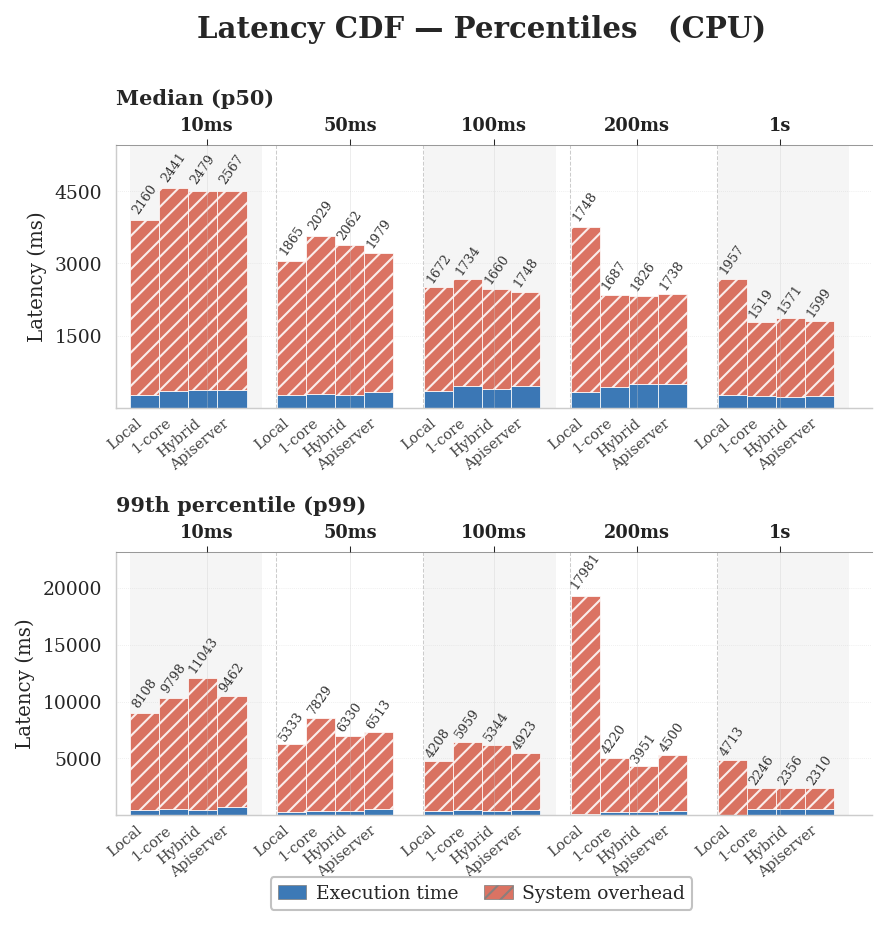

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch
from matplotlib.transforms import blended_transform_factory

# ──  ───────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          10,
    "axes.titlesize":     10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "axes.linewidth":     0.7,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
    "figure.dpi":         150,
})

# ── Data configuration ────────────────────────────────────────────────────────
DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s"]
ARCHS    = ["Hybrid", "Local", "Local 1core", "Local Apiserver"]
DATA_DIR = "."
FILES = {
    "Local":            {d: f"all_data_decomposed_{d}.csv"           for d in DELAYS},
    "Local 1core":      {d: f"all_data_decomposed_{d}_1core.csv"     for d in DELAYS},
    "Hybrid":           {d: f"all_data_decomposed_{d}_hybrid.csv"    for d in DELAYS},
    "Local Apiserver":  {d: f"all_data_decomposed_{d}_apiserver.csv" for d in DELAYS},
}

STACK_COLS    = ["execution_time_ms", "system_overhead_ms"]
STACK_LABELS  = ["Execution time", "System overhead"]
STACK_COLORS  = ["#2166AC", "#D6604D"]
STACK_HATCHES = ["", "///"]

REQ_TYPE = "cold"

# ── Helpers ───────────────────────────────────────────────────────────────────
def load(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df = df[(df["status"] == 200) & (df["type"] == REQ_TYPE)].copy()
    for col in STACK_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df if len(df) > 0 else None


def tail_decomp(df, pctile):
    thresh = np.percentile(df["latency_ms"].dropna(), pctile)
    tail   = df[df["latency_ms"] >= thresh]
    result = {col: (tail[col].mean() if len(tail) > 0 else 0) for col in STACK_COLS}
    result["n_tail"] = len(tail)
    result["thresh"] = thresh
    return result


available = [d for d in DELAYS if any(load(a, d) is not None for a in ARCHS)]
print(f"Delays ({REQ_TYPE}): {available}")

# ── Layout constants ──────────────────────────────────────────────────────────
PCTILES     = [50, 99]
ROW_TITLES  = ["Median (p50)", "99th percentile (p99)"]
ARCH_LABELS = ["Local", "1-core", "Hybrid", "Apiserver"]
N_ARCH      = len(ARCHS)
n           = len(available)

bar_w    = 0.17
gap      = 0.18
group_w  = N_ARCH * bar_w + gap
x_groups = np.arange(n) * group_w
x_arches = [x_groups + i * bar_w for i in range(N_ARCH)]
group_centers = x_groups + (N_ARCH * bar_w - bar_w) / 2

fig, axes = plt.subplots(
    len(PCTILES), 1,
    figsize=(6.5, 5.8),
    sharex=False,
    gridspec_kw={"hspace": 0.55},
)

for row, (pctile, row_title) in enumerate(zip(PCTILES, ROW_TITLES)):
    ax = axes[row]

    for ai, arch in enumerate(ARCHS):
        for ci, delay in enumerate(available):
            df = load(arch, delay)
            if df is None:
                continue
            decomp = tail_decomp(df, pctile)
            bottom = 0
            xpos   = x_arches[ai][ci]

            for col, color, hatch in zip(STACK_COLS, STACK_COLORS, STACK_HATCHES):
                val = decomp.get(col, 0)
                ax.bar(xpos, val, bottom=bottom, width=bar_w,
                       color=color, hatch=hatch, edgecolor="white",
                       linewidth=0.4, alpha=0.88, zorder=2)
                bottom += val

            # Threshold annotation above bar
            ax.text(xpos, bottom + max(bottom * 0.02, 1.5),
                    f"{decomp['thresh']:.0f}",
                    ha="center", va="bottom",
                    fontsize=6.2, color="#333333", rotation=55)

    # ── Fix ylim ─────────────────────────────────────────────────────────
    ax.autoscale_view()
    ylo, yhi = ax.get_ylim()
    ax.set_ylim(ylo, yhi * 1.14)

    # ── TOP x-axis: delay labels aligned with group centers ──────────────
    ax.spines["top"].set_visible(True)
    ax.spines["top"].set_linewidth(0.5)
    ax.spines["top"].set_color("0.60")

    ax2 = ax.twiny()                          # secondary x-axis on top
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(group_centers)
    ax2.set_xticklabels(available, fontsize=8.5, fontweight="bold",
                        color="#222222")
    ax2.tick_params(axis="x", direction="out", length=3, width=0.5,
                    pad=2, top=True)
    ax2.spines["top"].set_linewidth(0.5)
    ax2.spines["top"].set_color("0.60")
    ax2.spines["bottom"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Row title placed just to the left of the top ticks, bold
    ax2.set_title(row_title, fontsize=10, fontweight="bold",
                  loc="left", pad=6)

    # ── BOTTOM x-axis: arch labels, rotated ~45° ─────────────────────────
    # Hide default bottom ticks/labels
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=0)

    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for ai, label in enumerate(ARCH_LABELS):
        for ci in range(n):
            ax.text(x_arches[ai][ci], -0.03,
                    label,
                    ha="right", va="top",
                    fontsize=7, color="#444444",
                    transform=trans,
                    clip_on=False,
                    rotation=40)

    # Subtle group separators
    for ci in range(n - 1):
        sep_x = x_groups[ci] + N_ARCH * bar_w + gap / 2
        ax.axvline(sep_x, color="0.80", linewidth=0.5, linestyle="--", zorder=0)

    ax.set_ylabel("Latency (ms)", fontsize=9.5)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune="both"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.35, color="0.75", zorder=0)
    ax.tick_params(axis="y", direction="out", length=3, width=0.5)
    ax.set_xlim(x_groups[0] - bar_w, x_groups[-1] + N_ARCH * bar_w + bar_w * 0.8)

    # Alternating background shading
    for ci in range(n):
        if ci % 2 == 0:
            ax.axvspan(
                x_groups[ci] - bar_w * 0.5,
                x_groups[ci] + N_ARCH * bar_w + gap * 0.5 - bar_w * 0.5,
                color="0.96", zorder=0, linewidth=0)

# ── Shared legend (bottom center) ────────────────────────────────────────────
stack_handles = [
    Patch(facecolor=STACK_COLORS[i], hatch=STACK_HATCHES[i],
          label=STACK_LABELS[i], edgecolor="grey", linewidth=0.4, alpha=0.88)
    for i in range(len(STACK_COLS))
]
fig.legend(
    handles=stack_handles,
    loc="lower center",
    ncol=len(STACK_COLS),
    bbox_to_anchor=(0.5, -0.01),
    fontsize=9,
    framealpha=0.95,
    edgecolor="0.75",
    handlelength=1.5,
    handletextpad=0.5,
    columnspacing=1.4,
)
fig.suptitle("Latency CDF — Percentiles   (CPU)",
             fontsize=14, fontweight="bold", y=1.03)

plt.tight_layout(rect=[0, 0.0, 1, 1.0])

fig.savefig("fig_ecdf_iot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_ecdf_iot.png", dpi=300, bbox_inches="tight")
print("✓ fig_ecdf_iot.pdf / .png")

Delays (warm): ['10ms', '50ms', '100ms', '200ms', '1s']


/tmp/ipykernel_464591/426358880.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.98])


✓ fig_tail_warm_improved.pdf
✓ fig_tail_warm_improved.png


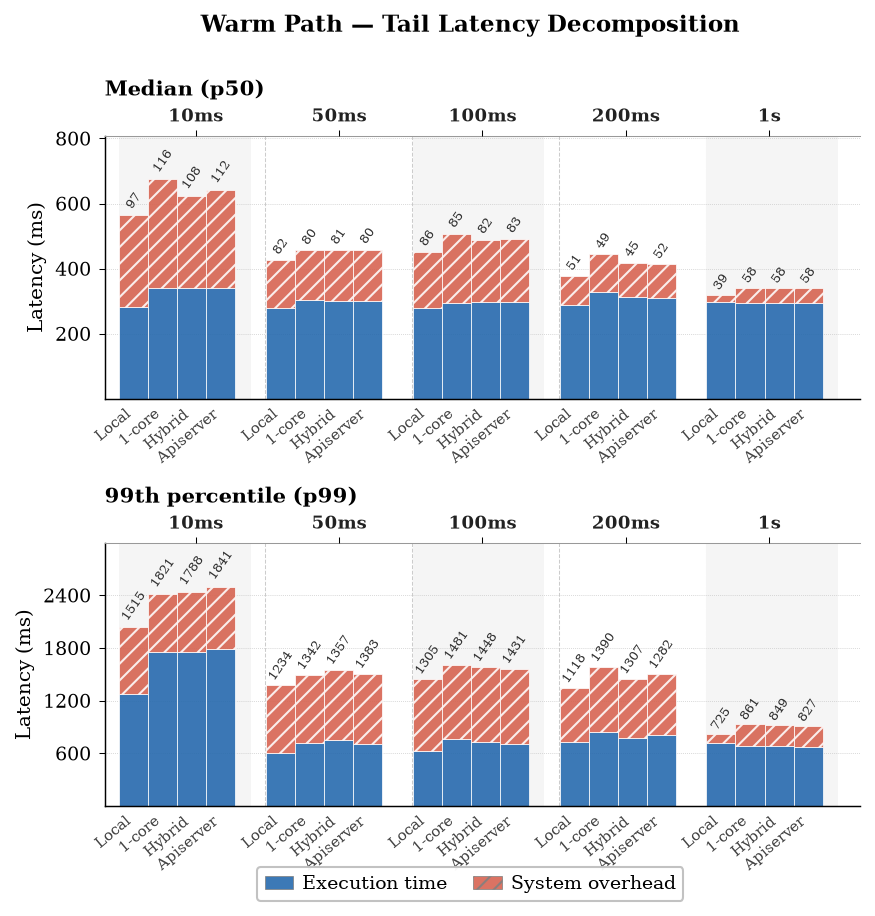

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch
from matplotlib.transforms import blended_transform_factory

# ──  ───────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          10,
    "axes.titlesize":     10,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "axes.linewidth":     0.7,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
    "figure.dpi":         150,
})

# ── Data configuration ────────────────────────────────────────────────────────
DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s"]
ARCHS    = ["Hybrid", "Local", "Local 1core", "Local Apiserver"]
DATA_DIR = "."
FILES = {
    "Local":            {d: f"all_data_decomposed_{d}.csv"           for d in DELAYS},
    "Local 1core":      {d: f"all_data_decomposed_{d}_1core.csv"     for d in DELAYS},
    "Hybrid":           {d: f"all_data_decomposed_{d}_hybrid.csv"    for d in DELAYS},
    "Local Apiserver":  {d: f"all_data_decomposed_{d}_apiserver.csv" for d in DELAYS},
}

STACK_COLS    = ["execution_time_ms", "system_overhead_ms"]
STACK_LABELS  = ["Execution time", "System overhead"]
STACK_COLORS  = ["#2166AC", "#D6604D"]
STACK_HATCHES = ["", "///"]

REQ_TYPE = "warm"

# ── Helpers ───────────────────────────────────────────────────────────────────
def load(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df = df[(df["status"] == 200) & (df["type"] == REQ_TYPE)].copy()
    for col in STACK_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df if len(df) > 0 else None


def tail_decomp(df, pctile):
    thresh = np.percentile(df["latency_ms"].dropna(), pctile)
    tail   = df[df["latency_ms"] >= thresh]
    result = {col: (tail[col].mean() if len(tail) > 0 else 0) for col in STACK_COLS}
    result["n_tail"] = len(tail)
    result["thresh"] = thresh
    return result


available = [d for d in DELAYS if any(load(a, d) is not None for a in ARCHS)]
print(f"Delays ({REQ_TYPE}): {available}")

# ── Layout constants ──────────────────────────────────────────────────────────
PCTILES     = [50, 99]
ROW_TITLES  = ["Median (p50)", "99th percentile (p99)"]
ARCH_LABELS = ["Local", "1-core", "Hybrid", "Apiserver"]
N_ARCH      = len(ARCHS)
n           = len(available)

bar_w    = 0.17
gap      = 0.18
group_w  = N_ARCH * bar_w + gap
x_groups = np.arange(n) * group_w
x_arches = [x_groups + i * bar_w for i in range(N_ARCH)]
group_centers = x_groups + (N_ARCH * bar_w - bar_w) / 2

fig, axes = plt.subplots(
    len(PCTILES), 1,
    figsize=(6.5, 5.8),
    sharex=False,
    gridspec_kw={"hspace": 0.55},
)

for row, (pctile, row_title) in enumerate(zip(PCTILES, ROW_TITLES)):
    ax = axes[row]

    for ai, arch in enumerate(ARCHS):
        for ci, delay in enumerate(available):
            df = load(arch, delay)
            if df is None:
                continue
            decomp = tail_decomp(df, pctile)
            bottom = 0
            xpos   = x_arches[ai][ci]

            for col, color, hatch in zip(STACK_COLS, STACK_COLORS, STACK_HATCHES):
                val = decomp.get(col, 0)
                ax.bar(xpos, val, bottom=bottom, width=bar_w,
                       color=color, hatch=hatch, edgecolor="white",
                       linewidth=0.4, alpha=0.88, zorder=2)
                bottom += val

            # Threshold annotation above bar
            ax.text(xpos, bottom + max(bottom * 0.02, 1.5),
                    f"{decomp['thresh']:.0f}",
                    ha="center", va="bottom",
                    fontsize=6.2, color="#333333", rotation=55)

    # ── Fix ylim ─────────────────────────────────────────────────────────
    ax.autoscale_view()
    ylo, yhi = ax.get_ylim()
    ax.set_ylim(ylo, yhi * 1.14)

    # ── TOP x-axis: delay labels aligned with group centers ──────────────
    ax.spines["top"].set_visible(True)
    ax.spines["top"].set_linewidth(0.5)
    ax.spines["top"].set_color("0.60")

    ax2 = ax.twiny()                          # secondary x-axis on top
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(group_centers)
    ax2.set_xticklabels(available, fontsize=8.5, fontweight="bold",
                        color="#222222")
    ax2.tick_params(axis="x", direction="out", length=3, width=0.5,
                    pad=2, top=True)
    ax2.spines["top"].set_linewidth(0.5)
    ax2.spines["top"].set_color("0.60")
    ax2.spines["bottom"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Row title placed just to the left of the top ticks, bold
    ax2.set_title(row_title, fontsize=10, fontweight="bold",
                  loc="left", pad=6)

    # ── BOTTOM x-axis: arch labels, rotated ~45° ─────────────────────────
    # Hide default bottom ticks/labels
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=0)

    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for ai, label in enumerate(ARCH_LABELS):
        for ci in range(n):
            ax.text(x_arches[ai][ci], -0.03,
                    label,
                    ha="right", va="top",
                    fontsize=7, color="#444444",
                    transform=trans,
                    clip_on=False,
                    rotation=40)

    # Subtle group separators
    for ci in range(n - 1):
        sep_x = x_groups[ci] + N_ARCH * bar_w + gap / 2
        ax.axvline(sep_x, color="0.80", linewidth=0.5, linestyle="--", zorder=0)

    ax.set_ylabel("Latency (ms)", fontsize=9.5)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune="both"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.35, color="0.75", zorder=0)
    ax.tick_params(axis="y", direction="out", length=3, width=0.5)
    ax.set_xlim(x_groups[0] - bar_w, x_groups[-1] + N_ARCH * bar_w + bar_w * 0.8)

    # Alternating background shading
    for ci in range(n):
        if ci % 2 == 0:
            ax.axvspan(
                x_groups[ci] - bar_w * 0.5,
                x_groups[ci] + N_ARCH * bar_w + gap * 0.5 - bar_w * 0.5,
                color="0.96", zorder=0, linewidth=0)

# ── Shared legend (bottom center) ────────────────────────────────────────────
stack_handles = [
    Patch(facecolor=STACK_COLORS[i], hatch=STACK_HATCHES[i],
          label=STACK_LABELS[i], edgecolor="grey", linewidth=0.4, alpha=0.88)
    for i in range(len(STACK_COLS))
]
fig.legend(
    handles=stack_handles,
    loc="lower center",
    ncol=len(STACK_COLS),
    bbox_to_anchor=(0.5, -0.01),
    fontsize=9,
    framealpha=0.95,
    edgecolor="0.75",
    handlelength=1.5,
    handletextpad=0.5,
    columnspacing=1.4,
)

fig.suptitle(
    "Warm Path — Tail Latency Decomposition",
    fontsize=11, fontweight="bold", y=1.02,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.98])

out_pdf = "fig_tail_warm_improved.pdf"
out_png = "fig_tail_warm_improved.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"✓ {out_pdf}")
print(f"✓ {out_png}")